# 02 - Patrones Temporales

**Pregunta de negocio:** ¿Cuándo se usan más los vehículos?

## Objetivos
- Visualizar series temporales de batería SOC para vehículos individuales
- Heatmaps de velocidad/actividad por hora y día de la semana
- Identificar picos de commute y tendencias de consumo

## Teoría
- **Serie temporal**: datos ordenados por tiempo — buscar tendencia, estacionalidad, ciclos
- **Heatmap temporal**: matriz hora×día muestra patrones cíclicos (commute, fines de semana)
- **Rolling average**: suaviza ruido para ver tendencias de largo plazo

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

In [2]:
# Cargar telemetría
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f, parse_dates=['timestamp']) for f in files], ignore_index=True)

fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Extraer componentes temporales
telemetry['hour'] = telemetry['timestamp'].dt.hour
telemetry['day_of_week'] = telemetry['timestamp'].dt.dayofweek  # 0=Lunes
telemetry['day_name'] = telemetry['timestamp'].dt.day_name()
telemetry['date'] = telemetry['timestamp'].dt.date

print(f"Registros: {len(telemetry):,}")
print(f"Rango: {telemetry['timestamp'].min()} → {telemetry['timestamp'].max()}")

Registros: 6,076,720
Rango: 2025-01-01 06:26:00 → 2025-01-30 22:59:03


## 1. Series temporales de batería SOC

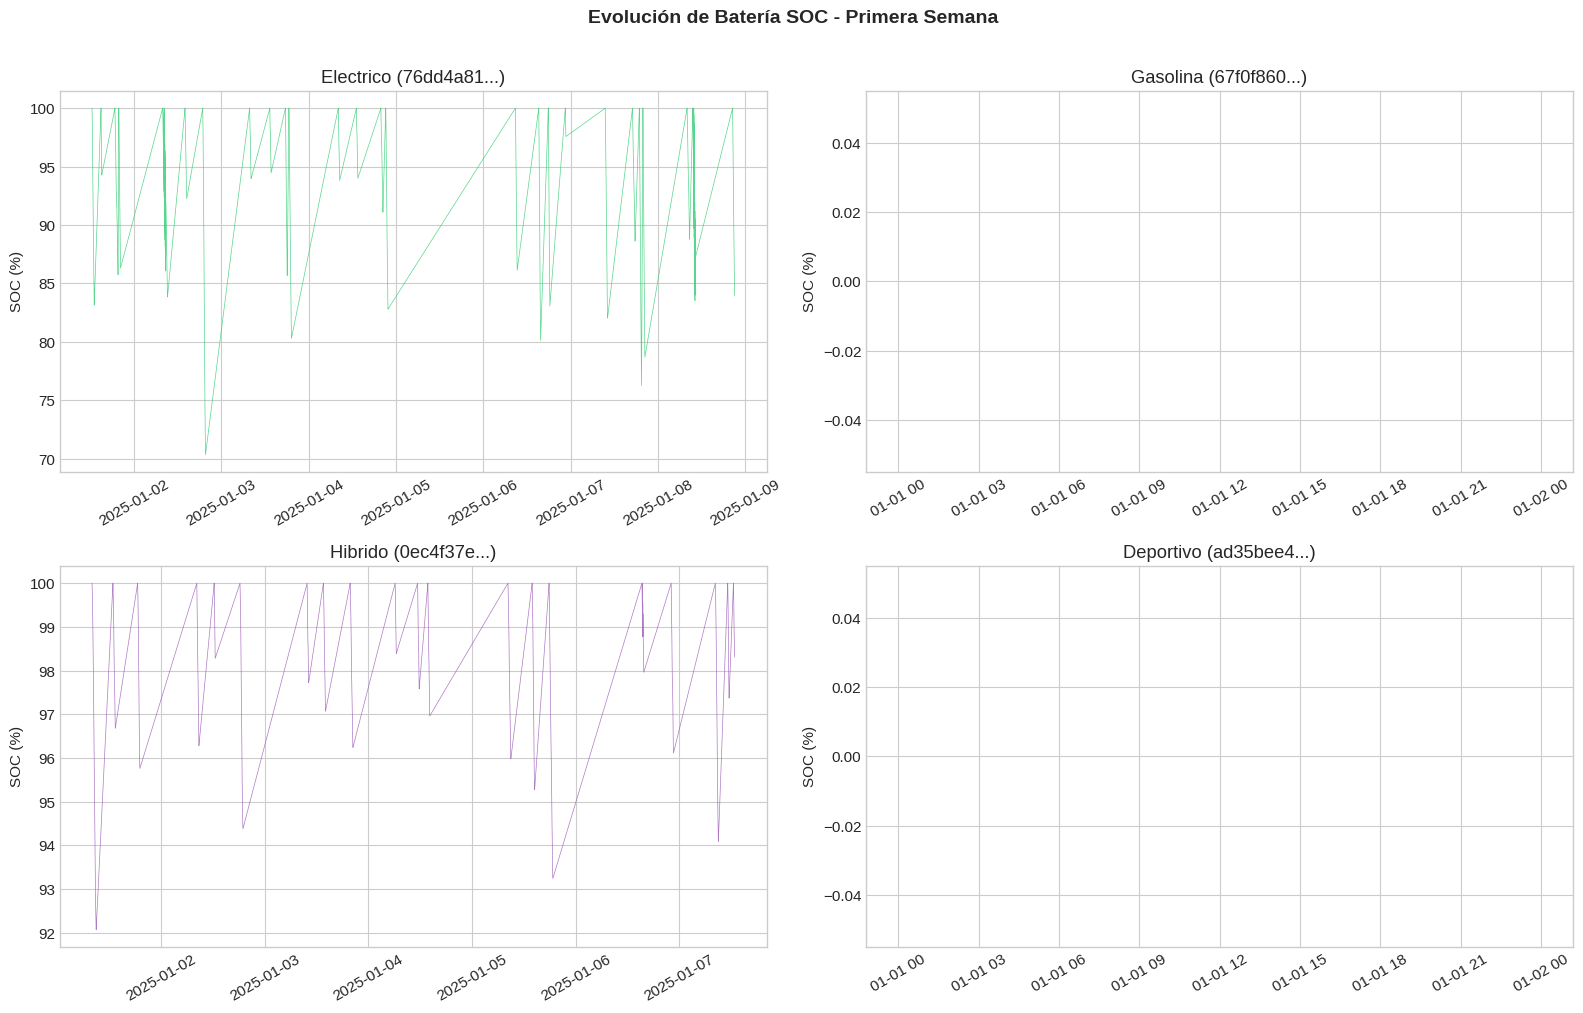

→ Se ven los ciclos diarios de uso (caídas) y posible recarga (subidas al inicio del viaje)


In [3]:
# Seleccionar 4 vehículos (uno de cada tipo) para la primera semana
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

for ax, vtype in zip(axes.flat, ['electrico', 'gasolina', 'hibrido', 'deportivo']):
    vid = telemetry[telemetry['vehicle_type'] == vtype]['vehicle_id'].unique()[0]
    v_data = telemetry[(telemetry['vehicle_id'] == vid)].sort_values('timestamp')
    # Solo primera semana
    first_week = v_data[v_data['date'] <= v_data['date'].unique()[6]]
    
    ax.plot(first_week['timestamp'], first_week['battery_soc_pct'], 
            linewidth=0.5, color=vtype_colors[vtype], alpha=0.8)
    ax.set_ylabel('SOC (%)')
    ax.set_title(f'{vtype.capitalize()} ({vid[:8]}...)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Evolución de Batería SOC - Primera Semana', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("→ Se ven los ciclos diarios de uso (caídas) y posible recarga (subidas al inicio del viaje)")

## 2. Heatmap: Actividad por hora y día de la semana

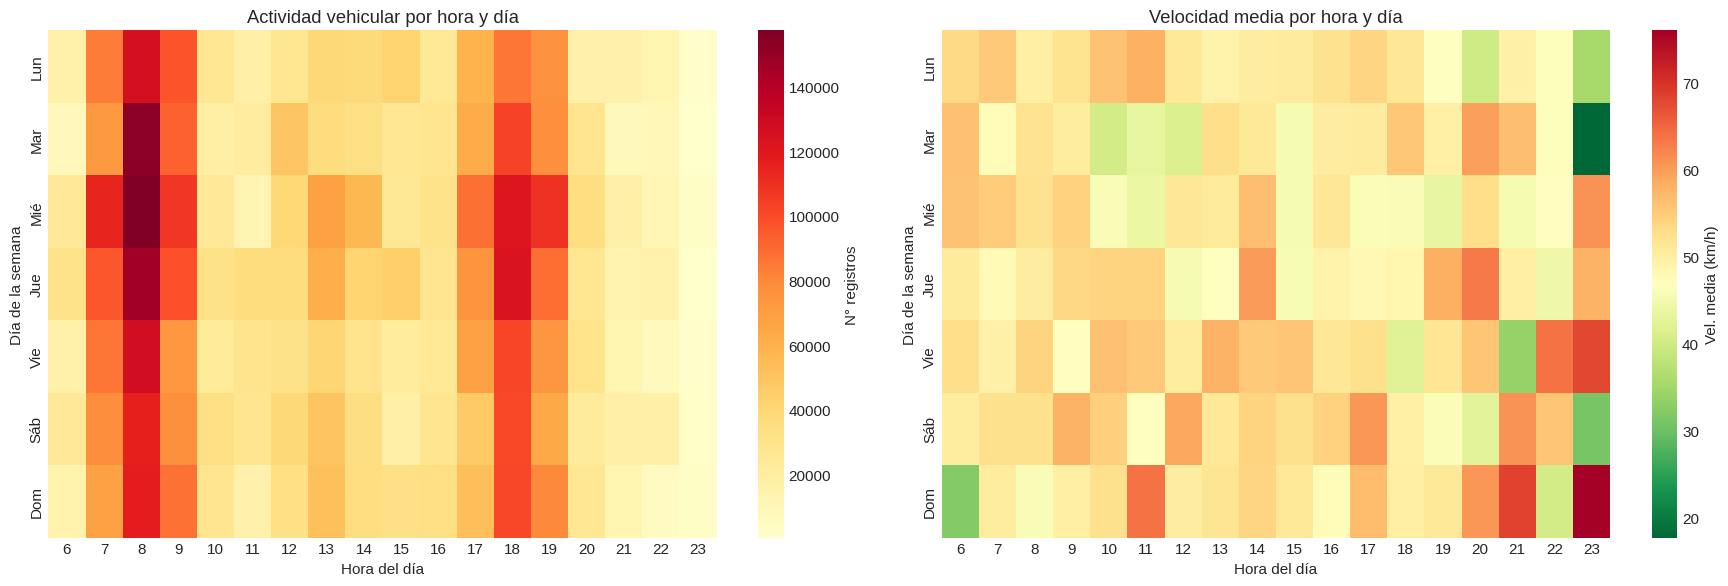

→ Busca los picos de commute (7-9h y 17-19h) y la menor actividad en fines de semana


In [4]:
# Contar registros (proxy de actividad) por hora y día
activity = telemetry.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
day_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap de actividad
sns.heatmap(activity, cmap='YlOrRd', ax=axes[0], 
            yticklabels=day_labels[:len(activity)], cbar_kws={'label': 'N° registros'})
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Día de la semana')
axes[0].set_title('Actividad vehicular por hora y día')

# Heatmap de velocidad media
speed_hm = telemetry.groupby(['day_of_week', 'hour'])['speed_kmh'].mean().unstack(fill_value=0)
sns.heatmap(speed_hm, cmap='RdYlGn_r', ax=axes[1],
            yticklabels=day_labels[:len(speed_hm)], cbar_kws={'label': 'Vel. media (km/h)'})
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Día de la semana')
axes[1].set_title('Velocidad media por hora y día')

plt.tight_layout()
plt.show()

print("→ Busca los picos de commute (7-9h y 17-19h) y la menor actividad en fines de semana")

## 3. Distribución de viajes por hora

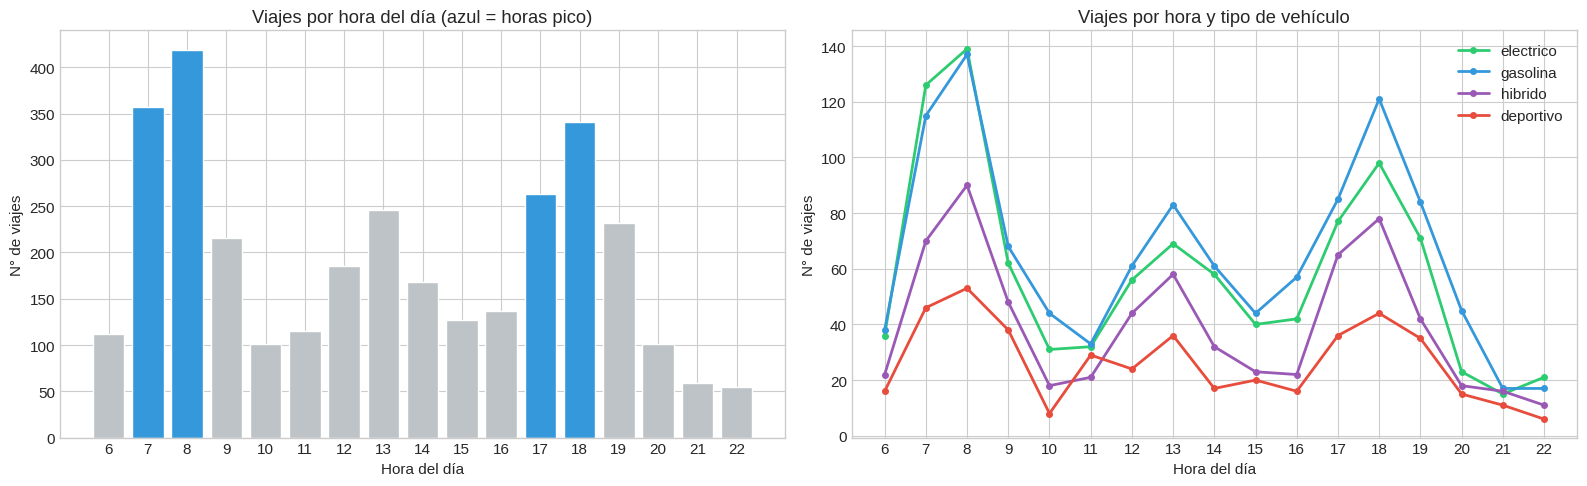

In [5]:
# Contar viajes únicos por hora de inicio
trip_starts = telemetry.groupby('trip_id').agg(
    start_hour=('hour', 'first'),
    vehicle_type=('vehicle_type', 'first'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total por hora
trips_by_hour = trip_starts['start_hour'].value_counts().sort_index()
colors_hour = ['#3498db' if h in [7, 8, 17, 18] else '#bdc3c7' for h in trips_by_hour.index]
axes[0].bar(trips_by_hour.index, trips_by_hour.values, color=colors_hour, edgecolor='white')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('N° de viajes')
axes[0].set_title('Viajes por hora del día (azul = horas pico)')
axes[0].set_xticks(range(6, 23))

# Por tipo de vehículo
for vtype in ['electrico', 'gasolina', 'hibrido', 'deportivo']:
    subset = trip_starts[trip_starts['vehicle_type'] == vtype]
    counts = subset['start_hour'].value_counts().sort_index()
    axes[1].plot(counts.index, counts.values, marker='o', markersize=4,
                 color=vtype_colors[vtype], label=vtype, linewidth=2)
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('N° de viajes')
axes[1].set_title('Viajes por hora y tipo de vehículo')
axes[1].legend()
axes[1].set_xticks(range(6, 23))

plt.tight_layout()
plt.show()

## 4. Tendencia de consumo a lo largo de los 30 días

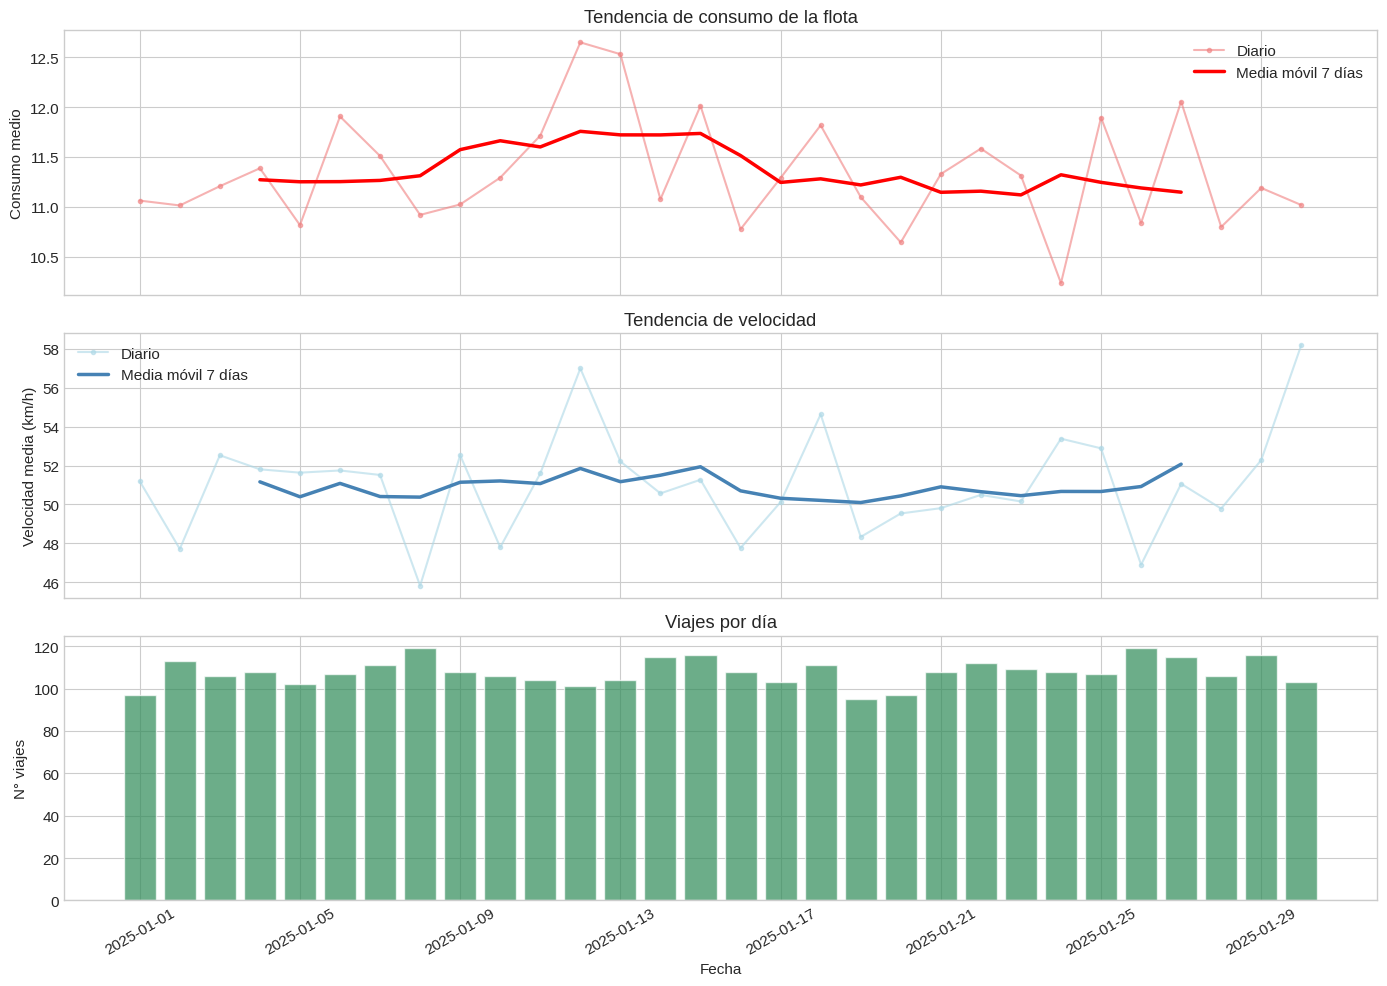

In [6]:
# Consumo diario promedio de la flota
daily_consumption = telemetry.groupby('date').agg(
    consumption_mean=('fuel_consumption_rate', 'mean'),
    speed_mean=('speed_kmh', 'mean'),
    n_trips=('trip_id', 'nunique'),
).reset_index()
daily_consumption['date'] = pd.to_datetime(daily_consumption['date'])

# Rolling average (ventana de 7 días)
daily_consumption['consumption_7d'] = daily_consumption['consumption_mean'].rolling(7, center=True).mean()
daily_consumption['speed_7d'] = daily_consumption['speed_mean'].rolling(7, center=True).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Consumo
axes[0].plot(daily_consumption['date'], daily_consumption['consumption_mean'],
             marker='o', markersize=3, color='lightcoral', alpha=0.6, label='Diario')
axes[0].plot(daily_consumption['date'], daily_consumption['consumption_7d'],
             linewidth=2.5, color='red', label='Media móvil 7 días')
axes[0].set_ylabel('Consumo medio')
axes[0].set_title('Tendencia de consumo de la flota')
axes[0].legend()

# Velocidad
axes[1].plot(daily_consumption['date'], daily_consumption['speed_mean'],
             marker='o', markersize=3, color='lightblue', alpha=0.6, label='Diario')
axes[1].plot(daily_consumption['date'], daily_consumption['speed_7d'],
             linewidth=2.5, color='steelblue', label='Media móvil 7 días')
axes[1].set_ylabel('Velocidad media (km/h)')
axes[1].set_title('Tendencia de velocidad')
axes[1].legend()

# N° viajes
axes[2].bar(daily_consumption['date'], daily_consumption['n_trips'], 
            color='seagreen', alpha=0.7, edgecolor='white')
axes[2].set_ylabel('N° viajes')
axes[2].set_title('Viajes por día')
axes[2].set_xlabel('Fecha')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Consumo por tipo de vehículo a lo largo del tiempo

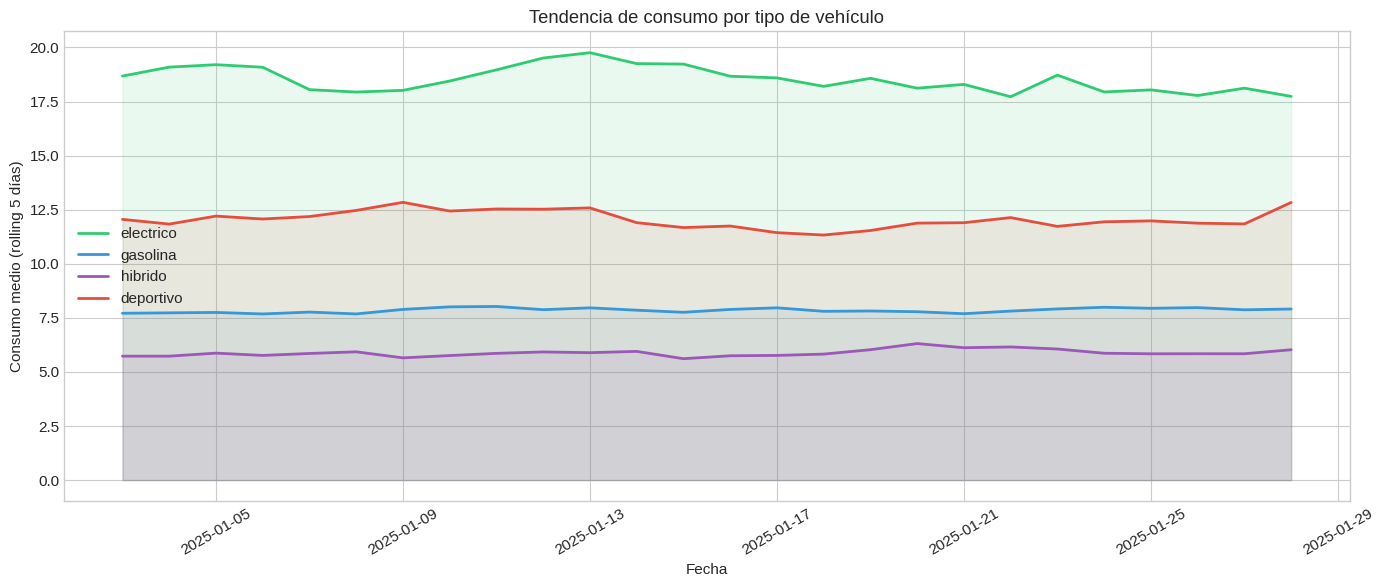

In [7]:
# Consumo diario por tipo
daily_by_type = telemetry.groupby(['date', 'vehicle_type'])['fuel_consumption_rate'].mean().reset_index()
daily_by_type['date'] = pd.to_datetime(daily_by_type['date'])

fig, ax = plt.subplots(figsize=(14, 6))

for vtype, color in vtype_colors.items():
    subset = daily_by_type[daily_by_type['vehicle_type'] == vtype].sort_values('date')
    rolling = subset['fuel_consumption_rate'].rolling(5, center=True).mean()
    ax.plot(subset['date'], rolling, linewidth=2, color=color, label=vtype)
    ax.fill_between(subset['date'], rolling, alpha=0.1, color=color)

ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo medio (rolling 5 días)')
ax.set_title('Tendencia de consumo por tipo de vehículo')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Resumen

### Respuesta:
> **¿Cuándo se usan más los vehículos?**
>
> Los picos de uso coinciden con horarios de commute (7-9h y 17-19h).
> La velocidad es mayor en horas tempranas (menos tráfico).
> Los eléctricos hacen más viajes cortos distribuidos en el día.
> El consumo se mantiene relativamente estable a lo largo del mes.

### Siguiente:
→ `03_survey_eda.ipynb`: Análisis exploratorio de encuestas